In [2]:
from model import SINDySz, SINDyModel
import torch
from matplotlib import pyplot as plt

/app/Repos/pytorchSINDySz/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
time_dim = 500
system_features = 2
latent_features = 4
poly_order = 2
batch_size = 2
model = SINDyModel(time_dim, system_features, latent_features,poly_order)
# Ensure model uses default dtype for consistency with loaded data
model = model.to(torch.get_default_dtype())
sindy_sz = SINDySz(model)

checkpoint = "/app/Repos/pytorchSINDySz/lightning_logs/version_11/checkpoints/epoch=2-step=213.ckpt"
core = SINDyModel(time_dim=500, system_features=2, latent_features=10, poly_order=2)
autoencoder = SINDySz.load_from_checkpoint(checkpoint, model=core)


Nonzeros>1e-05: 950/950 (100.00%)
Top-10 |weights|:
row 0, col 8, value 0.0000e+00, |.|=0.0000e+00
row 0, col 9, value 0.0000e+00, |.|=0.0000e+00
row 0, col 4, value 0.0000e+00, |.|=0.0000e+00
row 0, col 7, value 0.0000e+00, |.|=0.0000e+00
row 0, col 5, value 0.0000e+00, |.|=0.0000e+00
row 0, col 3, value 0.0000e+00, |.|=0.0000e+00
row 0, col 1, value 0.0000e+00, |.|=0.0000e+00
row 0, col 0, value 0.0000e+00, |.|=0.0000e+00
row 0, col 2, value 0.0000e+00, |.|=0.0000e+00
row 0, col 6, value 0.0000e+00, |.|=0.0000e+00


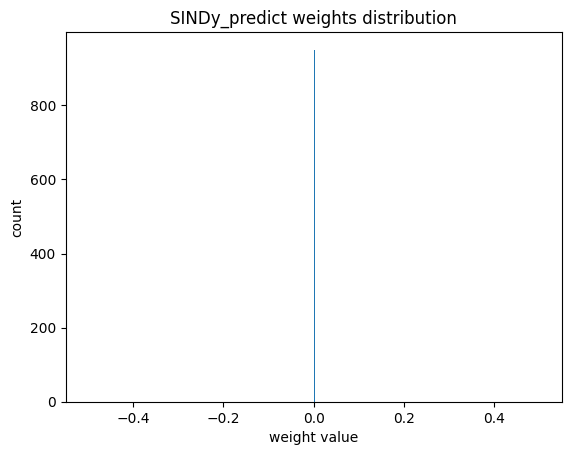

In [4]:
# grab weights/bias
W = autoencoder.model.SINDy_predict.weight.detach().cpu()
b = autoencoder.model.SINDy_predict.bias.detach().cpu()

# sparsity stats
thr = 1e-5  # tweak threshold for "effectively zero"
num_nonzero = (W.abs() < thr).sum().item()
total = W.numel()
print(f"Nonzeros>{thr}: {num_nonzero}/{total} ({num_nonzero/total:.2%})")

# top-10 magnitudes
flat_vals, flat_idx = torch.topk(W.abs().flatten(), k=10)
print("Top-10 |weights|:")
for v, idx in zip(flat_vals.tolist(), flat_idx.tolist()):
    row, col = divmod(idx, W.size(1))
    print(f"row {row}, col {col}, value {W[row, col].item():.4e}, |.|={v:.4e}")

# optional: histogram of magnitudes
import matplotlib.pyplot as plt
plt.hist(W.flatten().numpy(), bins=500)
plt.title("SINDy_predict weights distribution")
plt.xlabel("weight value")
plt.ylabel("count")
plt.show()


In [68]:
import torch
from torch.utils.data import DataLoader
from datasets import WRsmallepoch

# Keep dtype explicit to match model expectations
torch.set_default_dtype(torch.float32)


def get_example_batch(
    data_file="/app/Data/WR/WR5_Run4.hdf5",
    annotation_file="/app/Data/WR/Annotations/260218_annotations_a.pkl",
    batch_size=4,
    single_channel=False,
    psd=False,
    epoch_id=2.0,
    epoch_size=5.0,
    sample_rate=5000,
    shuffle=True,
):
    ds = WRsmallepoch(
        data_file=data_file,
        annotation_file=annotation_file,
        single_channel_flag=single_channel,
        psd_flag=psd,
        epoch_id_restriction=epoch_id,
        epoch_size=epoch_size,
        sample_rate=sample_rate,
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    data, labels = next(iter(loader))
    print(f"data shape: {tuple(data.shape)}, dtype: {data.dtype}")
    print(f"labels shape: {tuple(labels.shape)}, labels: {labels.tolist()}")
    return data, labels, ds.freq_weights

# Example usage in a notebook cell
data, labels, freq_weights = get_example_batch()


data shape: (4, 500, 2), dtype: torch.float32
labels shape: (4,), labels: [2, 2, 2, 2]


data shape: (4, 500, 2), dtype: torch.float32
labels shape: (4,), labels: [2, 2, 2, 2]
Per-item RMSE: [0.012597203254699707, 0.022640187293291092, 0.016687313094735146, 0.006251510698348284]


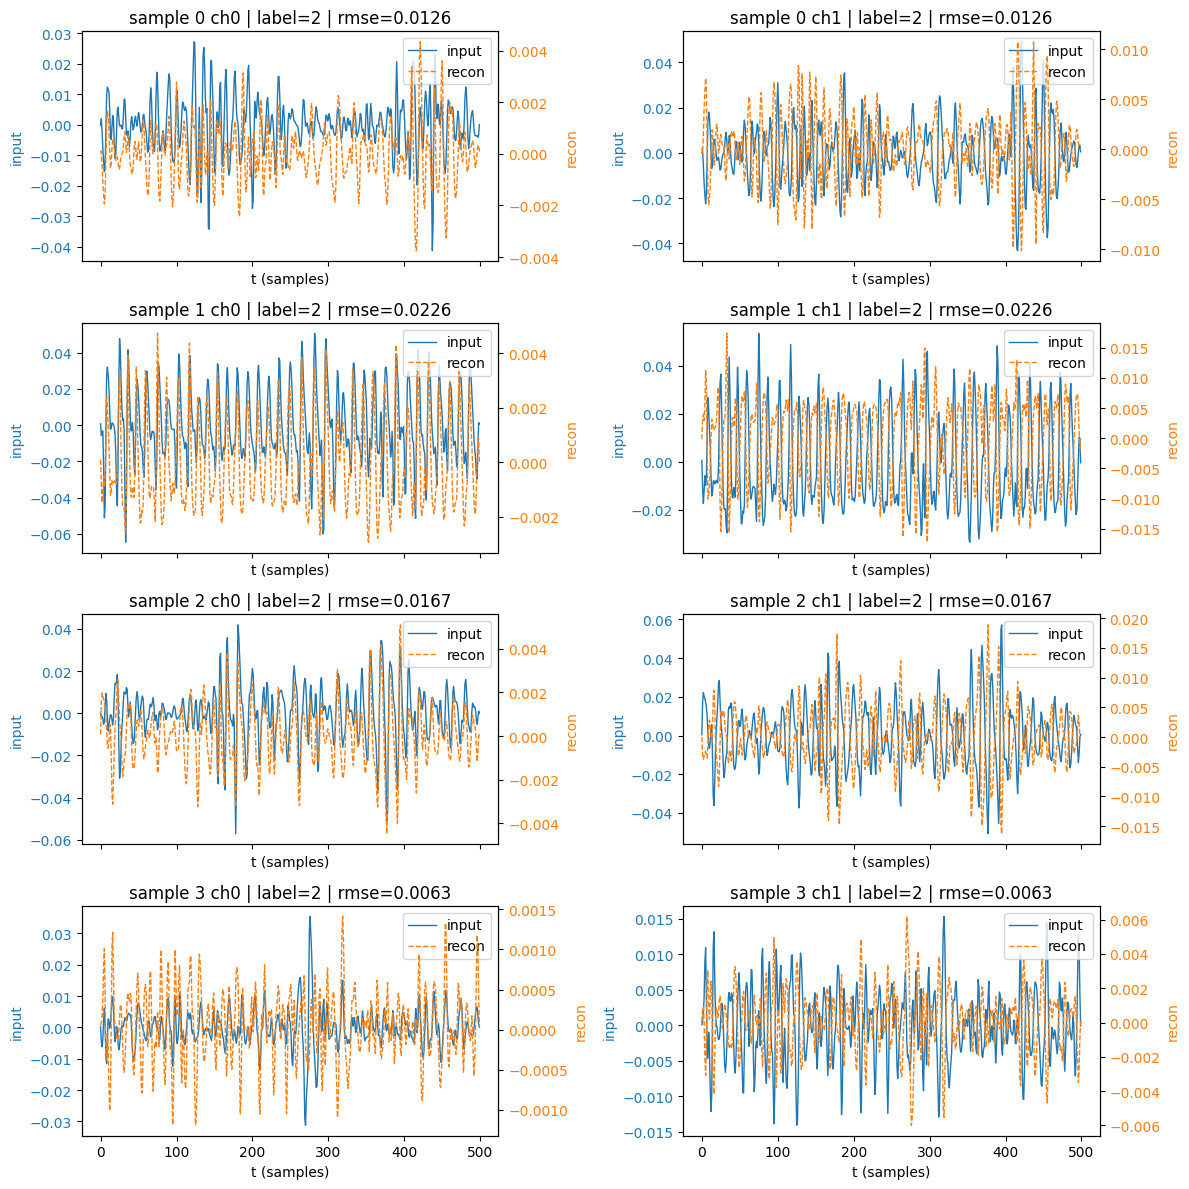

In [69]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

autoencoder = autoencoder.eval().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))


def inspect_recon_batch_dual_axes(data, labels, max_items=4, title_prefix="sample"):
    device = next(autoencoder.parameters()).device
    dtype = next(autoencoder.parameters()).dtype

    if data.dim() == 2:  # allow [B, T]
        data = data.unsqueeze(-1)

    # detached copies for plotting (never gain requires_grad)
    data_plot = data.detach().cpu()

    # clone for model so in-place requires_grad_ doesn’t touch plot copy
    data_model = data.detach().clone().to(device=device, dtype=dtype)
    labels_model = labels.to(device)

    with torch.no_grad():
        _, x_hat, _, _, _, _ = autoencoder(data_model)
    x_hat_plot = x_hat.detach().cpu()

    # per-item RMSE over time+channels
    per_item_rmse = F.mse_loss(x_hat_plot, data_plot, reduction="none").mean(dim=(1, 2)).sqrt()

    n = min(max_items, data_plot.size(0))
    channels = x_hat_plot.size(-1)
    fig, axes = plt.subplots(n, channels, figsize=(12, 3 * n), sharex=True)

    # normalize axes to 2D index
    if n == 1 and channels == 1:
        axes = [[axes]]
    elif n == 1:
        axes = [axes]
    elif channels == 1:
        axes = [[ax] for ax in axes]

    t = torch.arange(data_plot.size(1))
    for i in range(n):
        for ch in range(channels):
            ax_left = axes[i][ch]
            ax_right = ax_left.twinx()

            ax_left.plot(t, data_plot[i, :, ch], label="input", color="tab:blue", lw=1)
            ax_left.set_ylabel("input", color="tab:blue")
            ax_left.tick_params(axis='y', labelcolor="tab:blue")

            ax_right.plot(t, x_hat_plot[i, :, ch], label="recon", color="tab:orange", lw=1, linestyle="--")
            ax_right.set_ylabel("recon", color="tab:orange")
            ax_right.tick_params(axis='y', labelcolor="tab:orange")

            ax_left.set_title(
                f"{title_prefix} {i} ch{ch} | label={labels_model[i].item()} | rmse={per_item_rmse[i]:.4f}"
            )
            ax_left.set_xlabel("t (samples)")

            # manage legends: combine handles
            handles = [
                plt.Line2D([0], [0], color="tab:blue", lw=1, label="input"),
                plt.Line2D([0], [0], color="tab:orange", lw=1, linestyle="--", label="recon"),
            ]
            ax_left.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    return per_item_rmse

# Example: reuse the batch from get_example_batch (CPU tensors by default)
data, labels, freq_weights = get_example_batch()
rmse = inspect_recon_batch_dual_axes(data, labels)
print("Per-item RMSE:", rmse.tolist())


test data shape: (4, 500, 2), labels shape: (4,)
Test per-item RMSE: [0.007308455184102058, 0.01723896712064743, 0.012913606129586697, 0.012644477188587189]


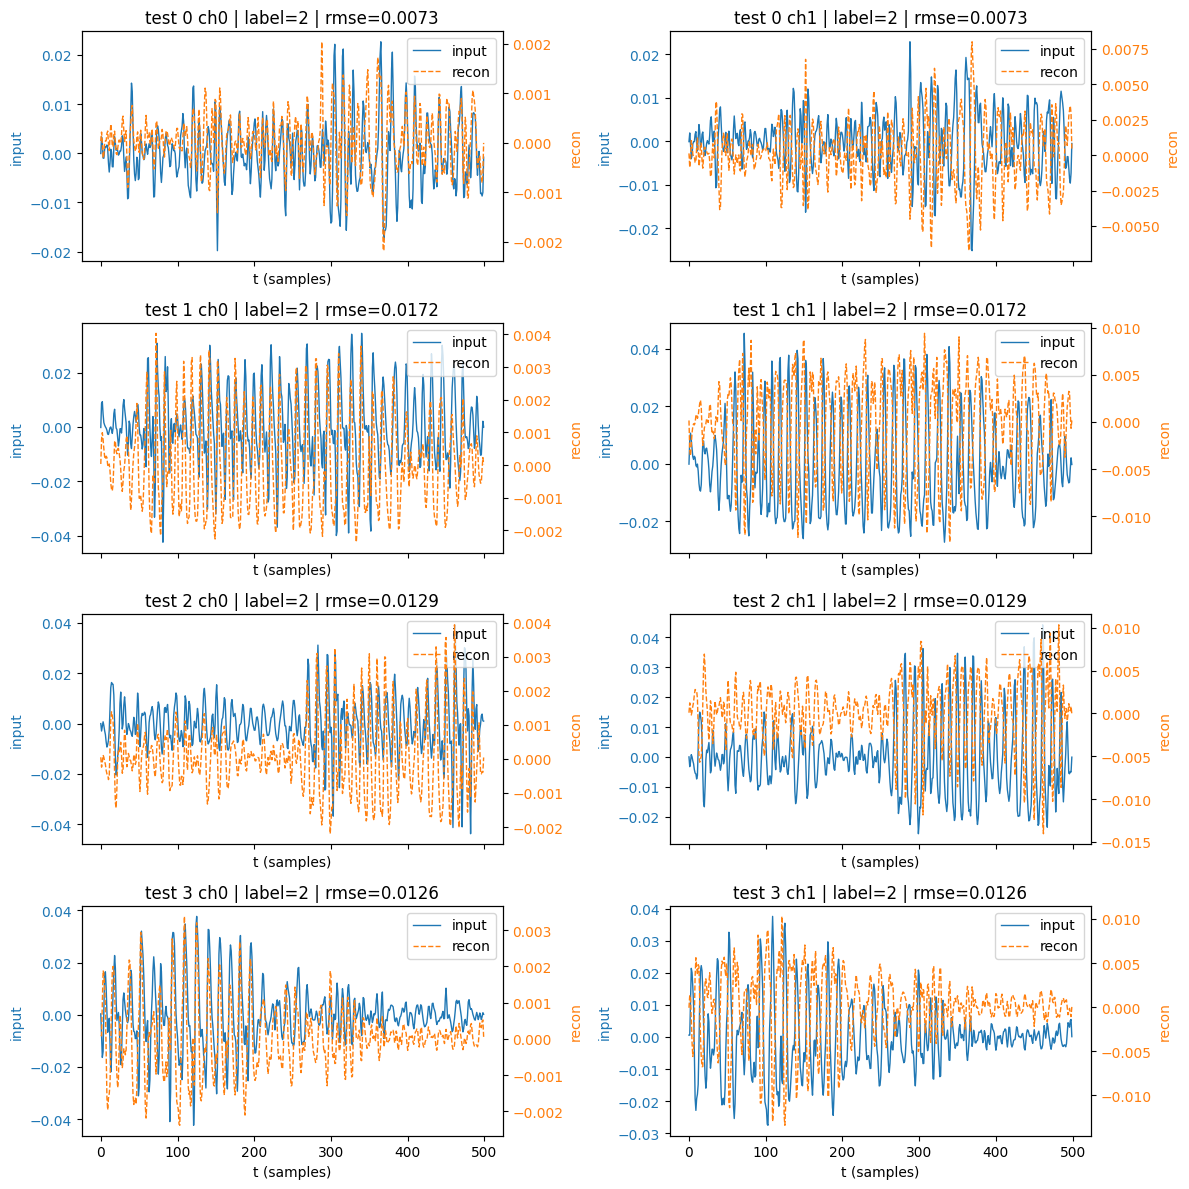

In [70]:
import torch
import torch.utils.data as data
from torch.utils.data import DataLoader
from datasets import WRsmallepoch

# pull one batch from the held-out 20% test split (no shuffle)
def get_test_batch(
    data_file="/app/Data/WR/WR5_Run4.hdf5",
    annotation_file="/app/Data/WR/Annotations/260218_annotations_a.pkl",
    batch_size=4,
    single_channel=False,
    psd=False,
    epoch_id=2.0,
    epoch_size=5.0,
    sample_rate=5000,
):
    ds = WRsmallepoch(
        data_file=data_file,
        annotation_file=annotation_file,
        single_channel_flag=single_channel,
        psd_flag=psd,
        epoch_id_restriction=epoch_id,
        epoch_size=epoch_size,
        sample_rate=sample_rate,
    )
    trv_size = int(len(ds) * 0.8)
    test_indices = list(range(trv_size, len(ds)))
    test_set = data.Subset(ds, test_indices)
    loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    batch = next(iter(loader))
    x, y = batch if isinstance(batch, (tuple, list)) else (batch, None)
    print(f"test data shape: {tuple(x.shape)}, labels shape: {tuple(y.shape) if y is not None else None}")
    return x, y

# Example: draw a test batch and plot reconstructions
test_data, test_labels = get_test_batch()
rmse_test = inspect_recon_batch_dual_axes(test_data, test_labels, title_prefix="test")
print("Test per-item RMSE:", rmse_test.tolist())


In [71]:
import torch
import pandas as pd
from itertools import combinations_with_replacement

# autoencoder already loaded from checkpoint
# autoencoder = SINDySz.load_from_checkpoint(checkpoint, model=core)

def _library_feature_names(latent_features=4, poly_order=2):
    names = []
    idx_range = list(range(latent_features))
    # polynomial terms first (same order as compute_library)
    for n in range(1, poly_order + 1):
        for combo in combinations_with_replacement(idx_range, n):
            combo_str = "*".join([f"z{c}" for c in combo])
            names.append(f"poly{n}_{combo_str}")
    # linear latent
    names.extend([f"z{c}" for c in idx_range])
    # Hilbert real/imag
    names.extend([f"hilbert_real_z{c}" for c in idx_range])
    names.extend([f"hilbert_imag_z{c}" for c in idx_range])
    return names

def list_nonzero_sindy_weights(threshold=1e-6):
    weight = autoencoder.model.SINDy_predict.weight.detach().cpu()  # [latent_features, library_dim]
    lf = weight.size(0)
    names = _library_feature_names(latent_features=lf, poly_order=autoencoder.model.poly_order)
    df = (
        pd.DataFrame(weight.numpy(), columns=names)
        .melt(ignore_index=False, var_name="feature", value_name="weight")
        .reset_index(names="latent_idx")
    )
    df["abs"] = df["weight"].abs()
    nz = df[df["abs"] > threshold].sort_values("abs", ascending=False)
    print(f"Non-zero (>|{threshold}|) weights: {len(nz)} of {len(df)}")
    return nz

nz_weights = list_nonzero_sindy_weights(threshold=1e-4)
display(nz_weights)


Non-zero (>|0.0001|) weights: 4 of 104


,latent_idx,feature,weight,abs
101,1,hilbert_imag_z3,0.000205,0.000205
8,0,poly1_z2,0.000169,0.000169
97,1,hilbert_imag_z2,0.000167,0.000167
56,0,z0,-0.000125,0.000125


In [72]:
import torch
from itertools import combinations_with_replacement

# assumes autoencoder = SINDySz.load_from_checkpoint(...)

def _library_feature_names(latent_features, poly_order):
    names = []
    idx_range = list(range(latent_features))
    for n in range(1, poly_order + 1):
        for combo in combinations_with_replacement(idx_range, n):
            names.append("*".join([f"z{k}" for k in combo]))
    names.extend([f"z{k}" for k in idx_range])
    names.extend([f"hilbert_real_z{k}" for k in idx_range])
    names.extend([f"hilbert_imag_z{k}" for k in idx_range])
    return names


def print_sindy_equations(model, threshold=1e-6):
    W = model.model.SINDy_predict.weight.detach().cpu()  # [L, library_dim]
    lf = W.size(0)
    names = _library_feature_names(lf, model.model.poly_order)
    for r in range(lf):
        terms = [f"{W[r, c].item():+0.3e}*{names[c]}" for c in range(W.size(1)) if abs(W[r, c]) > threshold]
        rhs = " + ".join(terms) if terms else "0"
        print(f"dz{r}/dt = {rhs}")

print_sindy_equations(autoencoder, threshold=1e-4)


dz0/dt = +1.692e-04*z2 + -1.247e-04*z0
dz1/dt = +1.673e-04*hilbert_imag_z2 + +2.047e-04*hilbert_imag_z3
dz2/dt = 0
dz3/dt = 0


test data shape: (4, 500, 2), labels shape: (4,)


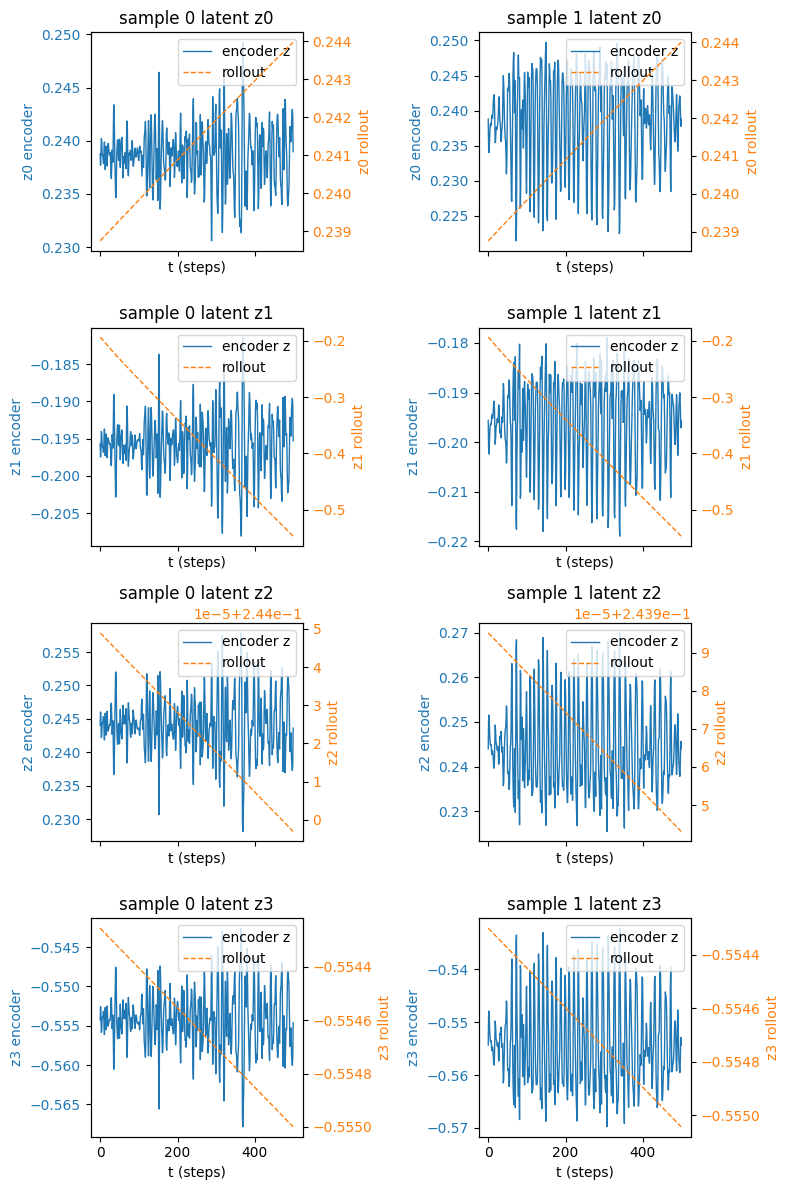

In [73]:
import torch
import matplotlib.pyplot as plt

autoencoder = autoencoder.eval().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

@torch.no_grad()
def latent_rollout_full_dual_axes(x_batch, steps=500, dt=1.0, max_items=2):
    """Roll out all latents with the full learned SINDy field and plot encoder vs rollout.

    Args:
        x_batch: input batch (B,T[,F])
        steps: rollout steps (clipped to observed T if smaller)
        dt: Euler step size
        max_items: max samples to plot
    Returns:
        (z_true_cpu, z_roll_cpu) on CPU
    """
    model = autoencoder.model
    device = next(autoencoder.parameters()).device
    dtype = next(autoencoder.parameters()).dtype

    # encode to latent
    if x_batch.dim() == 2:
        x_batch = x_batch.unsqueeze(-1)
    x_batch = x_batch.to(device=device, dtype=dtype)
    _, _, z_true, _, _, _ = autoencoder(x_batch)  # [B, T, L]

    B, T, L = z_true.shape
    steps = min(steps, max(T, steps))

    # rollout all latents using full compute_library + SINDy_predict
    z_roll = torch.zeros((B, steps, L), device=device, dtype=dtype)
    z_roll[:, 0, :] = z_true[:, 0, :]
    for t in range(steps - 1):
        theta = model.compute_library(z_roll[:, : t + 1, :])  # features from current rollout
        y_hat = model.SINDy_predict(theta)                    # dz/dt
        dz = y_hat[:, -1, :]
        z_roll[:, t + 1, :] = z_roll[:, t, :] + dt * dz       # Euler step

    # detach for plotting
    z_true_cpu = z_true[:, :steps, :].detach().cpu()
    z_roll_cpu = z_roll[:, :steps, :].detach().cpu()

    n = min(max_items, B)
    fig, axes = plt.subplots(L, n, figsize=(4 * n, 3 * L), sharex=True)
    if L == 1 and n == 1:
        axes = [[axes]]
    elif L == 1:
        axes = [axes]
    elif n == 1:
        axes = [[ax] for ax in axes]

    t_axis = torch.arange(steps)
    for l in range(L):  # z0..z3
        for bi in range(n):
            ax_left = axes[l][bi]
            ax_right = ax_left.twinx()

            ax_left.plot(t_axis, z_true_cpu[bi, :, l], color="tab:blue", lw=1, label="encoder z")
            ax_left.set_ylabel(f"z{l} encoder", color="tab:blue")
            ax_left.tick_params(axis='y', labelcolor="tab:blue")

            ax_right.plot(t_axis, z_roll_cpu[bi, :, l], color="tab:orange", lw=1, linestyle="--", label="rollout")
            ax_right.set_ylabel(f"z{l} rollout", color="tab:orange")
            ax_right.tick_params(axis='y', labelcolor="tab:orange")

            ax_left.set_title(f"sample {bi} latent z{l}")
            ax_left.set_xlabel("t (steps)")
            handles = [
                plt.Line2D([0], [0], color="tab:blue", lw=1, label="encoder z"),
                plt.Line2D([0], [0], color="tab:orange", lw=1, linestyle="--", label="rollout"),
            ]
            ax_left.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    return z_true_cpu, z_roll_cpu

# Example usage
test_data, test_labels = get_test_batch()
z_true_cpu, z_roll_cpu = latent_rollout_full_dual_axes(test_data)
